# cuVS CAGRA build + concurrent search benchmark

Sweeps `(size, dim, search_concurrency)` and measures build time, recall@k, search wall, and effective QPS.

- METRIC = squared L2; params live in `index_size_params.yaml`.
- **All** cuVS search timing and neighbors (every `search_c`, including `1`) go through the **`cuvs_search_client`** binary — same C API path as high concurrency (`std::async` × `c`).

## How a search request flows

```text
┌─ Notebook (Python) ──────────────────────────────────────────────┐
│  build CAGRA → save index → write queries.bin → spawn child      │
└──────────────────────────────│───────────────────────────────────┘
                               ▼
┌─ C++ binary (one process, one CUDA context) ────────────────────┐
│  cuvsCagraDeserialize(index)                                    │
│  search_params.persistent = true                                │
│  warmup → launches persistent kernel (stays resident)           │
│                                                                 │
│      std::async × c                                             │
│      ┌───────────┐                                              │
│      │ thread 0  │ ──┐                                          │
│      │ thread 1  │   │  drop 1-query searches into the          │
│      │   ...     │   ├─►kernel queue (~hundreds in flight)      │
│      │ thread c-1│ ──┘                                          │
│      └───────────┘                                              │
└──────────────────────────────│──────────────────────────────────┘
                               ▼
┌─ Persistent CAGRA kernel (GPU) ──────────────────────────────────┐
│  queue: [q0][q1][q2]…[qN]   ← always full while threads submit   │
│  CTA 0: q0 │ CTA 1: q1 │ CTA 2: q2 │ … │ CTA n: qn               │
│  each CTA traverses the graph and writes top-k to n_dev/d_dev    │
└──────────────────────────────│───────────────────────────────────┘
                               ▼
┌─ C++ binary ────────────────────────────────────────────────────┐
│  cudaMemcpy n_dev → host  → write neighbors.bin + meta.json     │
└──────────────────────────────│──────────────────────────────────┘
                               ▼
┌─ Notebook ──────────────────────────────────────────────────────┐
│  np.fromfile → reshape → recall vs ground truth → QPS → plot    │
└─────────────────────────────────────────────────────────────────┘
```

In [1]:
import multiprocessing as _mp
import os
import struct
import time

import cupy  # noqa: F401
import numpy as np
import pandas as pd
import yaml
from cuvs.neighbors import brute_force  # noqa: F401
from tqdm import tqdm

SCRIPT_DIR = os.path.abspath(".")
DATASET_PATH = os.environ.get("CUVS_DATASET_PATH", "/raid/scripts/datasets/miracl-5M")
BASE_FILE = f"{DATASET_PATH}/base.fbin"
QUERY_FILE = f"{DATASET_PATH}/query.fbin"

with open(os.path.join(SCRIPT_DIR, "index_size_params.yaml")) as f:
    PARAMS = yaml.safe_load(f)
# One index type or several: str or list/tuple of str (e.g. ["cagra", "faiss_hnsw"]).
INDEX_TYPE = ["cagra", "faiss_hnsw"]   # "cagra" | "ivf_pq" | "faiss_hnsw" | ["cagra", "faiss_hnsw"]
CUVS_BUILD_ALGO = str(PARAMS.get("cagra", PARAMS.get("cuvs", {})).get("build_algo", "nn_descent"))

# Benchmark sweeps.
SIZES = [1_000_000]
BENCHMARK_DIMS = [1024]
SEARCH_CONCURRENCY = [1,2,4,8,16,32,64, 128]   # in-flight searches per call (c). int or list.
SEARCH_BATCH_SIZES = [1]  # queries per client search call (bs). int or list.
PROCESS_SEARCH_ITERS = 2        # timed iters averaged in the C++ client

K = 10
METRIC = "sqeuclidean"

def _aslist(x):
    return [int(v) for v in (x if isinstance(x, (list, tuple)) else [x])]


def _as_index_types(x):
    allowed = {"cagra", "ivf_pq", "faiss_hnsw"}
    if isinstance(x, (list, tuple)):
        t = [str(v).strip() for v in x]
        if not t:
            raise ValueError("INDEX_TYPE list is empty")
    else:
        t = [str(x).strip()]
    bad = [v for v in t if v not in allowed]
    if bad:
        raise ValueError(f"Unknown INDEX_TYPE {bad}; allowed: {sorted(allowed)}")
    return t


_INDEX_TYPES = _as_index_types(INDEX_TYPE)
_RESULTS_CSV_STEM = "_".join(_INDEX_TYPES) if len(_INDEX_TYPES) > 1 else _INDEX_TYPES[0]
INDEX_TYPE = _INDEX_TYPES[0]  # str for run_benchmark / ad-hoc cells; benchmark loop reassigns

_SEARCH_C_LEVELS = _aslist(SEARCH_CONCURRENCY)
_SEARCH_BS_LEVELS = _aslist(SEARCH_BATCH_SIZES)
# FAISS: use many OMP threads for index.add only; search still uses 1 thread per in-flight search.
FAISS_BUILD_OMP_THREADS = int(os.environ.get("FAISS_BUILD_OMP_THREADS", _mp.cpu_count() or 1))
print(
    f"index={_INDEX_TYPES} | c={_SEARCH_C_LEVELS} | bs={_SEARCH_BS_LEVELS} | "
    f"cagra_build_algo={CUVS_BUILD_ALGO} | faiss_build_omp={FAISS_BUILD_OMP_THREADS}"
)

index=['cagra', 'faiss_hnsw'] | c=[1, 2, 4, 8, 16, 32, 64, 128] | bs=[1] | cagra_build_algo=nn_descent | faiss_build_omp=64


In [2]:
def load_fbin(path, max_rows=None):
    """Load .fbin file (header: n_vectors, dim as uint32; data: float32)."""
    with open(path, "rb") as f:
        n, dim = struct.unpack("<II", f.read(8))
        if max_rows is not None:
            n = min(n, max_rows)
        data = np.fromfile(f, dtype=np.float32, count=n * dim)
    return data.reshape(n, dim).astype(np.float32)

def get_dataset_shape(path):
    """Read (n_vectors, dim) from fbin header without loading data."""
    with open(path, "rb") as f:
        n, dim = struct.unpack("<II", f.read(8))
    return n, dim

n_base, dim = get_dataset_shape(BASE_FILE)
n_queries, _ = get_dataset_shape(QUERY_FILE)
print(f"Base: {n_base:,} x {dim}, Queries: {n_queries:,}")

# Trim sizes to available data
SIZES = [s for s in SIZES if s <= n_base]
if not SIZES:
    SIZES = [min(10_000, n_base), n_base]
print(f"Benchmark sizes: {SIZES}")

# Dimension sweep (BENCHMARK_DIMS from config cell; None / [] => full dim only)
if BENCHMARK_DIMS is None or BENCHMARK_DIMS == []:
    BENCHMARK_DIMS = [dim]
else:
    BENCHMARK_DIMS = [int(d) for d in BENCHMARK_DIMS]
    bad = [d for d in BENCHMARK_DIMS if not (1 <= d <= dim)]
    if bad:
        raise ValueError(f"BENCHMARK_DIMS must be in [1, {dim}]; invalid: {bad}")
print(f"Benchmark dimensions: {BENCHMARK_DIMS}")

Base: 4,990,000 x 2048, Queries: 10,000
Benchmark sizes: [1000000]
Benchmark dimensions: [1024]


In [3]:
# Load base via mmap (avoids loading full 20GB into RAM when subsampling)
# Query file is small, load fully.
print("Loading base and query data...")
base_mmap = np.memmap(BASE_FILE, dtype=np.float32, mode="r", offset=8, shape=(n_base, dim))
queries = load_fbin(QUERY_FILE)

def get_base_slice(size):
    """Return base[:size] as contiguous float32 (needed for some libraries)."""
    return np.ascontiguousarray(base_mmap[:size].astype(np.float32))


def truncate_to_dim(x, d):
    """Keep the first d dimensions (columns); output is contiguous float32."""
    return np.ascontiguousarray(np.asarray(x, dtype=np.float32)[:, :d])


print(f"Base: {n_base:,} x {dim} (mmap), Queries: {queries.shape}")

Loading base and query data...
Base: 4,990,000 x 2048 (mmap), Queries: (10000, 2048)


In [4]:
def calc_recall(ann_idx, true_nn_idx):
    """Recall@K: proportion of true neighbors found."""
    ann = np.asarray(ann_idx, dtype=np.int64)
    gt = np.asarray(true_nn_idx, dtype=np.int64)
    return sum(np.intersect1d(ann[i], gt[i]).size for i in range(ann.shape[0])) / ann.size

def compute_groundtruth(base, queries, k):
    """Brute-force KNN ground truth on GPU (same METRIC as the indexed search)."""
    import gc
    import cupy as cp
    from cuvs.neighbors import brute_force

    base_gpu = cp.asarray(base.astype(np.float32))
    queries_gpu = cp.asarray(queries.astype(np.float32))
    index = brute_force.build(base_gpu, metric=METRIC)
    _, idx = brute_force.search(index, queries_gpu, k)
    if hasattr(idx, "copy_to_host"):
        idx_host = np.asarray(idx.copy_to_host(), dtype=np.int64)
    elif hasattr(idx, "get"):
        idx_host = np.asarray(idx.get(), dtype=np.int64)
    else:
        idx_host = np.asarray(cp.asarray(idx), dtype=np.int64)
    del base_gpu, queries_gpu, index, idx
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()
    return idx_host

In [5]:
def build_cuvs_index(base):
    """Build cuVS index once per (size, dim); search uses search_cuvs_index."""
    import cupy as cp
    from cuvs.neighbors import cagra, ivf_pq

    base_gpu = cp.asarray(base)
    if INDEX_TYPE == "cagra":
        p = PARAMS["cagra"]
        itopk = int(p.get("itopk_size", 64))
        sw = max(1, int(p.get("search_width", 1)))
        persistent = bool(p.get("persistent", False))
        t0 = time.perf_counter()
        idx = cagra.build(
            cagra.IndexParams(
                metric=METRIC,
                graph_degree=p["graph_degree"],
                intermediate_graph_degree=p["intermediate_graph_degree"],
                build_algo=CUVS_BUILD_ALGO,
            ),
            base_gpu,
        )
        t_build = time.perf_counter() - t0
        save_fn = cagra.save
        search_params = cagra.SearchParams(itopk_size=itopk, persistent=persistent, search_width=sw)
        neigh_dtype = cp.uint32
        cli_extra = [
            "--itopk-size",
            str(itopk),
            "--persistent",
            "1" if persistent else "0",
            "--search-width",
            str(sw),
        ]
    elif INDEX_TYPE == "ivf_pq":
        p = PARAMS["ivf_pq"]
        n_probes = int(p.get("n_probes", 32))
        t0 = time.perf_counter()
        idx = ivf_pq.build(ivf_pq.IndexParams(metric=METRIC, n_lists=int(p["n_lists"])), base_gpu)
        t_build = time.perf_counter() - t0
        save_fn = ivf_pq.save
        search_params = ivf_pq.SearchParams(n_probes=n_probes)
        neigh_dtype = np.int64
        cli_extra = ["--n-probes", str(n_probes)]
    else:
        raise ValueError(f"Unknown INDEX_TYPE: {INDEX_TYPE}")
    return {
        "idx": idx,
        "build_time_s": t_build,
        "save_fn": save_fn,
        "search_params": search_params,
        "neigh_dtype": neigh_dtype,
        "cli_extra": cli_extra,
    }


def search_cuvs_index(bundle, queries, k, search_concurrency, batch_size, cpp_index_state):
    """Search only via `cuvs_search_client` (all `search_c`, including 1).

    cpp_index_state: {\"path\": None|str}; serialized index written once per build.
    """
    import json
    import subprocess
    import tempfile

    sc, bs = int(search_concurrency), max(1, int(batch_size))
    queries_cpu = np.asarray(queries, dtype=np.float32)
    nq = int(queries_cpu.shape[0])
    idx = bundle["idx"]
    save_fn = bundle["save_fn"]
    cli_extra = bundle["cli_extra"]

    if cpp_index_state["path"] is None:
        fd, cpp_index_state["path"] = tempfile.mkstemp(prefix="cuvs_idx_", suffix=".bin")
        os.close(fd)
        save_fn(cpp_index_state["path"], idx)
    index_file = cpp_index_state["path"]
    files = [
        tempfile.NamedTemporaryFile(prefix=f"cuvs_{n}_", suffix=s, delete=False).name
        for n, s in [("q", ".bin"), ("n", ".bin"), ("m", ".json")]
    ]
    queries_file, neighbors_file, meta_file = files
    try:
        queries_cpu.tofile(queries_file)
        subprocess.run(
            [
                os.path.join(SCRIPT_DIR, "cuvs_search_client"),
                "--algo",
                INDEX_TYPE,
                "--index-file",
                index_file,
                "--queries-file",
                queries_file,
                "--out-neighbors",
                neighbors_file,
                "--out-meta",
                meta_file,
                "--shape",
                f"{nq},{queries_cpu.shape[1]}",
                "--k",
                str(int(k)),
                "--c",
                str(max(1, sc)),
                "--batch-size",
                str(bs),
                "--iters",
                str(int(PROCESS_SEARCH_ITERS)),
                *cli_extra,
            ],
            check=True,
        )
        np_dtype = np.uint32 if INDEX_TYPE == "cagra" else np.int64
        neighbors = np.fromfile(neighbors_file, dtype=np_dtype).reshape(nq, k).astype(np.int64)
        with open(meta_file) as f:
            wall = float(json.load(f)["search_wall_s"])
    finally:
        for fp in files:
            if os.path.exists(fp):
                os.remove(fp)
    total_q = nq

    return {
        "neighbors": neighbors,
        "search_wall_s": wall,
        "search_qps_effective": total_q / wall if wall > 0 else float("nan"),
    }


def benchmark_cuvs_index(base, queries, k, search_concurrency=1, batch_size=1):
    """Legacy one-shot build+search (uses build once + search once)."""
    b = build_cuvs_index(base)
    r = search_cuvs_index(b, queries, k, search_concurrency, batch_size, {"path": None})
    r["build_time_s"] = b["build_time_s"]
    return r

In [6]:
def build_faiss_hnsw_index(base):
    """Build FAISS HNSW once; uses FAISS_BUILD_OMP_THREADS for index.add."""
    import faiss

    fa = PARAMS["faiss"]
    faiss.omp_set_num_threads(max(1, int(FAISS_BUILD_OMP_THREADS)))
    base_c = np.ascontiguousarray(base.astype(np.float32))
    index = faiss.IndexHNSWFlat(base_c.shape[1], fa["M"], faiss.METRIC_L2)
    index.hnsw.efConstruction = fa["ef_construction"]
    index.hnsw.efSearch = fa["ef_search"]
    t0 = time.perf_counter()
    index.add(base_c)
    t_build = time.perf_counter() - t0
    return index, t_build


def search_faiss_hnsw_index(index, queries, k, search_concurrency=1, batch_size=1):
    """Search only: 1 OMP thread per faiss.search; c Python threads for concurrency."""
    import faiss
    from concurrent.futures import ThreadPoolExecutor

    faiss.omp_set_num_threads(1)
    sc, bs = int(search_concurrency), max(1, int(batch_size))
    queries_c = np.ascontiguousarray(queries.astype(np.float32))
    nq = int(queries_c.shape[0])
    out_neigh = np.empty((nq, k), dtype=np.int64)
    slices = [(s, min(s + bs, nq)) for s in range(0, nq, bs)]

    def worker(s_e):
        s, e = s_e
        _, n = index.search(queries_c[s:e], k)
        out_neigh[s:e] = n.astype(np.int64)

    worker(slices[0])
    t0 = time.perf_counter()
    if sc <= 1:
        for sl in slices:
            worker(sl)
    else:
        with ThreadPoolExecutor(max_workers=sc) as ex:
            list(ex.map(worker, slices))
    wall = time.perf_counter() - t0
    return {
        "neighbors": out_neigh,
        "search_wall_s": wall,
        "search_qps_effective": nq / wall if wall > 0 else float("nan"),
    }


def benchmark_faiss_hnsw(base, queries, k, search_concurrency=1, batch_size=1):
    """Legacy one-shot build+search."""
    idx, t_build = build_faiss_hnsw_index(base)
    r = search_faiss_hnsw_index(idx, queries, k, search_concurrency, batch_size)
    r["build_time_s"] = t_build
    return r

In [7]:
def run_benchmark(size, d, c, bs):
    import gc
    base = truncate_to_dim(get_base_slice(size), d)
    queries_sub = truncate_to_dim(queries.astype(np.float32), d)
    gt = compute_groundtruth(base, queries_sub, K)
    gc.collect()

    if INDEX_TYPE == "faiss_hnsw":
        r = benchmark_faiss_hnsw(base, queries_sub, K, c, bs)
        build_algo = "faiss"
    else:
        r = benchmark_cuvs_index(base, queries_sub, K, c, bs)
        build_algo = CUVS_BUILD_ALGO

    return {
        "size": size, "dim": d, "k": K, "search_c": int(c), "batch_size": int(bs),
        "index_type": INDEX_TYPE,
        "build_algo": build_algo,
        "build_s": r["build_time_s"],
        "recall": calc_recall(r["neighbors"], gt),
        "search_wall_s": r["search_wall_s"],
        "search_qps_effective": r["search_qps_effective"],
    }


In [8]:
rows = []
for d in tqdm(BENCHMARK_DIMS, desc="Dim"):
    for size in tqdm(SIZES, desc=f"n (d={d})", leave=False):
        import gc

        base = truncate_to_dim(get_base_slice(size), d)
        queries_sub = truncate_to_dim(queries.astype(np.float32), d)
        gt = compute_groundtruth(base, queries_sub, K)
        gc.collect()

        for INDEX_TYPE in tqdm(_INDEX_TYPES, desc=f"index (n={size})", leave=False):
            if INDEX_TYPE == "faiss_hnsw":
                idx, t_build = build_faiss_hnsw_index(base)
                try:
                    for c in tqdm(_SEARCH_C_LEVELS, desc=f"c ({INDEX_TYPE} n={size})", leave=False):
                        for bs in _SEARCH_BS_LEVELS:
                            r = search_faiss_hnsw_index(idx, queries_sub, K, c, bs)
                            rows.append(
                                {
                                    "size": size,
                                    "dim": d,
                                    "k": K,
                                    "search_c": int(c),
                                    "batch_size": int(bs),
                                    "index_type": INDEX_TYPE,
                                    "build_algo": "faiss",
                                    "build_s": t_build,
                                    "recall": calc_recall(r["neighbors"], gt),
                                    "search_wall_s": r["search_wall_s"],
                                    "search_qps_effective": r["search_qps_effective"],
                                }
                            )
                finally:
                    del idx
            else:
                bundle = build_cuvs_index(base)
                cpp_state = {"path": None}
                try:
                    for c in tqdm(_SEARCH_C_LEVELS, desc=f"c ({INDEX_TYPE} n={size})", leave=False):
                        for bs in _SEARCH_BS_LEVELS:
                            r = search_cuvs_index(bundle, queries_sub, K, c, bs, cpp_state)
                            rows.append(
                                {
                                    "size": size,
                                    "dim": d,
                                    "k": K,
                                    "search_c": int(c),
                                    "batch_size": int(bs),
                                    "index_type": INDEX_TYPE,
                                    "build_algo": CUVS_BUILD_ALGO,
                                    "build_s": bundle["build_time_s"],
                                    "recall": calc_recall(r["neighbors"], gt),
                                    "search_wall_s": r["search_wall_s"],
                                    "search_qps_effective": r["search_qps_effective"],
                                }
                            )
                finally:
                    pth = cpp_state["path"]
                    if pth and os.path.exists(pth):
                        os.remove(pth)
                    del bundle["idx"]
                    gc.collect()
                    try:
                        import cupy as cp

                        cp.get_default_memory_pool().free_all_blocks()
                    except Exception:
                        pass

df = pd.DataFrame(rows)
df


Dim:   0%|          | 0/1 [00:00<?, ?it/s]


[3037707][02:36:48:341140][info  ] Initialized the kernel 0x73242bfb45b0 in stream 126595301954224; job_queue size = 8192; worker_queue size = 881
[3037707][02:36:52:341445][info  ] Destroyed the persistent runner.
[3037739][02:36:52:344693][info  ] Initialized the kernel 0x73242bfb45b0 in stream 126595100627632; job_queue size = 8192; worker_queue size = 55


[3057852][02:37:06:668250][info  ] Initialized the kernel 0x71576c3b45b0 in stream 124616395772592; job_queue size = 8192; worker_queue size = 881
[3057852][02:37:10:668535][info  ] Destroyed the persistent runner.
[3057881][02:37:10:672403][info  ] Initialized the kernel 0x71576c3b45b0 in stream 124616328663728; job_queue size = 8192; worker_queue size = 55


[3077956][02:37:19:237436][info  ] Initialized the kernel 0x7755e0fb45b0 in stream 131206888870576; job_queue size = 8192; worker_queue size = 881
[3077956][02:37:23:237724][info  ] Destroyed the persistent runner.
[3077984][02:3

,size,dim,k,search_c,batch_size,index_type,build_algo,build_s,recall,search_wall_s,search_qps_effective
0,1000000,1024,10,1,1,cagra,nn_descent,21.302350,0.93118,5.612300,1781.800688
1,1000000,1024,10,2,1,cagra,nn_descent,21.302350,0.93118,2.731630,3660.817900
2,1000000,1024,10,4,1,cagra,nn_descent,21.302350,0.93118,1.336300,7483.349547
3,1000000,1024,10,8,1,cagra,nn_descent,21.302350,0.93118,0.679827,14709.624655
4,1000000,1024,10,16,1,cagra,nn_descent,21.302350,0.93118,0.386449,25876.635727
5,1000000,1024,10,32,1,cagra,nn_descent,21.302350,0.93118,0.310283,32228.642884
6,1000000,1024,10,64,1,cagra,nn_descent,21.302350,0.93118,0.324746,30793.296915
7,1000000,1024,10,128,1,cagra,nn_descent,21.302350,0.93118,0.373123,26800.813673
8,1000000,1024,10,1,1,faiss_hnsw,faiss,262.880724,0.93879,6.575004,1520.911712
9,1000000,1024,10,2,1,faiss_hnsw,faiss,262.880724,0.93879,3.674367,2721.557534


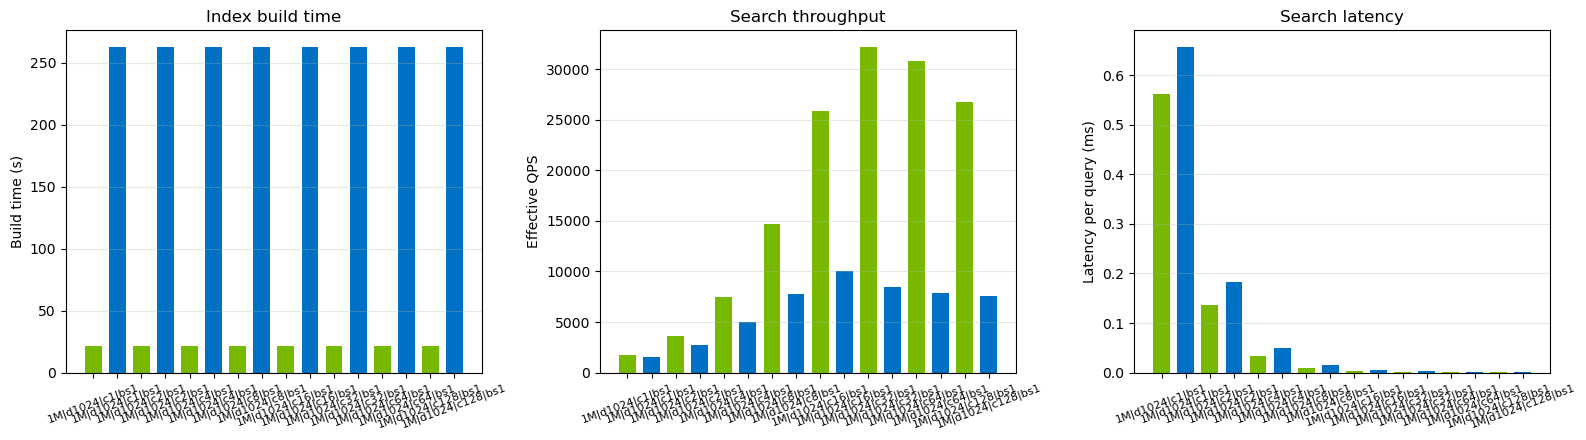

,size,dim,search_c,batch_size,index_type,build_algo,build_s,search_wall_s,search_qps_effective,recall
0,1000000,1024,1,1,cagra,nn_descent,21.3023,5.6123,1781.8007,0.9312
1,1000000,1024,1,1,faiss_hnsw,faiss,262.8807,6.5750,1520.9117,0.9388
2,1000000,1024,2,1,cagra,nn_descent,21.3023,2.7316,3660.8179,0.9312
3,1000000,1024,2,1,faiss_hnsw,faiss,262.8807,3.6744,2721.5575,0.9388
4,1000000,1024,4,1,cagra,nn_descent,21.3023,1.3363,7483.3495,0.9312
5,1000000,1024,4,1,faiss_hnsw,faiss,262.8807,1.9815,5046.5777,0.9388
6,1000000,1024,8,1,cagra,nn_descent,21.3023,0.6798,14709.6247,0.9312
7,1000000,1024,8,1,faiss_hnsw,faiss,262.8807,1.2870,7769.8906,0.9388
8,1000000,1024,16,1,cagra,nn_descent,21.3023,0.3864,25876.6357,0.9312
9,1000000,1024,16,1,faiss_hnsw,faiss,262.8807,0.9995,10004.9909,0.9388


In [10]:
import matplotlib.pyplot as plt

COLOR = {"cagra": "#76b900", "ivf_pq": "#a64dff", "faiss_hnsw": "#0071c5"}
plot_df = df.sort_values(["size", "dim", "search_c", "batch_size"]).reset_index(drop=True)
plot_df["latency_ms"] = 1000.0 * plot_df["search_wall_s"] / (n_queries * plot_df["search_c"])
labels = plot_df.apply(
    lambda r: f"{int(r['size']/1e6)}M|d{int(r['dim'])}|c{int(r['search_c'])}|bs{int(r['batch_size'])}", axis=1
).tolist()
x = np.arange(len(plot_df))
color = plot_df["index_type"].map(COLOR).fillna("#888").tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, ylabel, title in [
    (axes[0], "build_s", "Build time (s)", "Index build time"),
    (axes[1], "search_qps_effective", "Effective QPS", "Search throughput"),
    (axes[2], "latency_ms", "Latency per query (ms)", "Search latency"),
]:
    ax.bar(x, plot_df[col], 0.7, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, fontsize=8)
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

summary_df = plot_df[[
    "size", "dim", "search_c", "batch_size", "index_type", "build_algo",
    "build_s", "search_wall_s", "search_qps_effective", "recall",
]].round(4)
summary_df.to_csv(f"results_{_RESULTS_CSV_STEM}.csv", index=False)
summary_df
